# Feed-Forward Neural Networks (FFNN) Model

In [408]:
# Import necessary libraries 
import numpy as np         
import pandas as pd       
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch               
import torch.nn as nn      
import torch.optim as optim 
import torch.nn.functional as F 
from torch.utils.data import DataLoader, TensorDataset

In [409]:
# Setting the correct seed 
def set_reproducibility(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Reproducibility set with seed: {seed}")

set_reproducibility(42)

Reproducibility set with seed: 42


In [410]:
# Check if a NVIDIA GPU is available via CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU detected. Running on CPU. (For FFNNs on small data, this is fine!)")

No GPU detected. Running on CPU. (For FFNNs on small data, this is fine!)


In [ ]:
# Path to my data 
data_path = "project/microsoft_corp/data_clean.csv"

# Reading the data 
data = pd.read_csv(data_path, parse_dates=['date'])

# Adjust the index 
data = data.set_index('date')

# Display cleaned time series dataset
display(data.head())

,volume,adjprice,oil,gold,sp500,vix,rates_10y
date,,,,,,,
2010-01-04,38409100.0,23.077383,81.510002,1117.699951,1132.989990,20.040001,3.841
2010-01-05,49749600.0,23.084843,81.769997,1118.099976,1136.520020,19.350000,3.755
2010-01-06,58182400.0,22.943165,83.180000,1135.900024,1137.140015,19.160000,3.808
2010-01-07,50559700.0,22.704561,82.660004,1133.099976,1141.689941,19.059999,3.822
2010-01-08,51197400.0,22.861149,82.750000,1138.199951,1144.979980,18.129999,3.808


In [412]:
# Verying the data 
data.head(5)

,volume,adjprice,oil,gold,sp500,vix,rates_10y
date,,,,,,,
2010-01-04,38409100.0,23.077383,81.510002,1117.699951,1132.989990,20.040001,3.841
2010-01-05,49749600.0,23.084843,81.769997,1118.099976,1136.520020,19.350000,3.755
2010-01-06,58182400.0,22.943165,83.180000,1135.900024,1137.140015,19.160000,3.808
2010-01-07,50559700.0,22.704561,82.660004,1133.099976,1141.689941,19.059999,3.822
2010-01-08,51197400.0,22.861149,82.750000,1138.199951,1144.979980,18.129999,3.808


In [413]:
data.describe()

,volume,adjprice,oil,gold,sp500,vix,rates_10y
count,4.024000e+03,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,3.529555e+07,149.293493,71.532062,1663.167211,2945.011381,18.412875,2.604174
std,2.058245e+07,145.119517,20.799435,584.726810,1491.073720,6.873274,1.004028
min,5.855900e+06,17.315042,-37.630001,1050.800049,1022.580017,9.140000,0.499000
25%,2.192250e+07,30.767126,54.167499,1268.475006,1805.630035,13.770000,1.853000
50%,2.938710e+07,78.815315,71.555000,1505.700012,2584.730103,16.660000,2.458500
75%,4.318792e+07,250.818756,88.265001,1830.049988,4078.204956,21.100000,3.334750
max,3.193179e+08,539.825256,123.699997,4529.100098,6932.049805,82.690002,4.988000


In [414]:
# Creating the dataset: univariate setup, predicting the adjprice with 7 past days 
def create_dataset(series, window_size, lead_time):
    X, y = [], []
    
    # Ensure data is in numpy format for easier indexing
    if isinstance(series, pd.Series) or isinstance(series, pd.DataFrame):
        data = series.values
    else:
        data = series

    # We loop through the data, stopping before we run out of future values to predict
    for i in range(len(data) - window_size - lead_time + 1):
        # Input (X): past d data 
        X.append(data[i : i + window_size])

        # Output(Y): single h value steps ahed 
        y.append(data[i + window_size + lead_time - 1])

    return np.array(X), np.array(y)

In [415]:
# Create the dataset using the parameters and the function defined 
target_col = 'adjprice'
window_size = 7
lead_time = 1

X_raw, y_raw = create_dataset(data[target_col], window_size=window_size, lead_time=lead_time)

print("Dataset Construction Complete.")
print(f"Shape of X: {X_raw.shape}  -> (n_samples, window_size)")
print(f"Shape of y: {y_raw.shape}      -> (n_samples,)")

Dataset Construction Complete.
Shape of X: (4017, 7)  -> (n_samples, window_size)
Shape of y: (4017,)      -> (n_samples,)


In [416]:
# As before, we take until 2019 for training, until 2022 for validation and then until 2026 for test
y_dates = data.index[window_size + lead_time - 1:]
train_end_idx = np.where(y_dates.year <= 2019)[0][-1] + 1
val_end_idx = np.where(y_dates.year <= 2022)[0][-1] + 1

# Creating the NumPy arrays
X_train_np, y_train_np = X_raw[:train_end_idx], y_raw[:train_end_idx]
X_val_np, y_val_np     = X_raw[train_end_idx:val_end_idx], y_raw[train_end_idx:val_end_idx]
X_test_np, y_test_np   = X_raw[val_end_idx:], y_raw[val_end_idx:]

print(f"Split Summary:")
print(f"Training set:   {X_train_np.shape[0]} days (2012-2019)")
print(f"Validation set: {X_val_np.shape[0]} days (2020-2022)")
print(f"Test set:       {X_test_np.shape[0]} days (2023-2025)")

Split Summary:
Training set:   2509 days (2012-2019)
Validation set: 756 days (2020-2022)
Test set:       752 days (2023-2025)


## Dealing with tensors 

In [417]:
# Conversion to Tensors
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
y_val_t = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

print("Conversion to Tensors complete.")
print(f"Input shape: {X_train_t.shape} (Samples, Window Size)")
print(f"Target shape: {y_train_t.shape} (Samples, 1)")

Conversion to Tensors complete.
Input shape: torch.Size([2509, 7]) (Samples, Window Size)
Target shape: torch.Size([2509, 1]) (Samples, 1)


In [418]:
# Definition of the FFNN model using nn.sequential 
class PriceForecaster(nn.Module):
    def __init__(self, input_dim):
        """
        Constructor where we define the layers of the network.
        input_dim: The number of past time steps (window_size).
        """
        super(PriceForecaster, self).__init__()

        # We define a sequential block of layers
        self.network = nn.Sequential(
            # --- Layer 1 ---
            # Linear transformation from Input (7) to Hidden 1 (32 nodes)
            nn.Linear(input_dim, 32),
            # ReLU Activation: f(x) = max(0, x). Introduces non-linearity.
            nn.ReLU(),  # <--- CHANGE/TRY: nn.Sigmoid() or nn.Tanh()
            nn.Dropout(0.3),

            # --- Layer 2 ---
            # Linear transformation from Hidden 1 (32) to Hidden 2 (16 nodes)
            nn.Linear(32, 16),
            nn.ReLU(),  # <--- CHANGE/TRY: nn.Sigmoid() or nn.Tanh()
            nn.Dropout(0.3),

            # --- Output Layer ---
            # Final transformation to a single continuous value
            nn.Linear(16, 1)
        )

    def forward(self, x):
        """
        Defines the 'forward pass' of the model.
        It describes how the input tensor x travels through the layers
        to produce the prediction.
        """
        return self.network(x)

# --- Instantiate the Model ---
# We pass window_size (7) as the input dimension.
model = PriceForecaster(input_dim=window_size)

# Print the model structure to verify the architecture
print("FFNN Model Structure:")
print(model)

FFNN Model Structure:
PriceForecaster(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [419]:
# Using the functional method inside torch 
class PriceForecaster(nn.Module):
    def __init__(self, input_dim):
        """
        In this version, we define each layer as an individual attribute.
        """
        super(PriceForecaster, self).__init__()

        # Define the layers individually
        self.fc1 = nn.Linear(input_dim, 256)  # Fully Connected Layer 1
        self.fc2 = nn.Linear(256, 128)         # Fully Connected Layer 2
        self.fc3 = nn.Linear(128, 1)          # Output Layer

    def forward(self, x):
        """
        The forward pass defines the path step-by-step.
        This gives you more control to print shapes or add logic between layers.
        """
        # Pass through the first layer and apply ReLU activation
        x = self.fc1(x)
        x = F.relu(x)

        # Pass through the second layer and apply ReLU activation
        x = self.fc2(x)
        x = F.relu(x)

        # Final output layer (no activation for regression tasks)
        out = self.fc3(x)

        return out

# --- Instantiate the Model ---
model = PriceForecaster(input_dim=window_size)

# Print the model structure
print("Functional FFNN Model Structure:")
print(model)

Functional FFNN Model Structure:
PriceForecaster(
  (fc1): Linear(in_features=7, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)


In [420]:
# --- 1. Define Hyperparameters ---
# The learning rate is typically a small number between 1e-2 and 1e-5
learning_rate = 0.01

# One 'epoch' means the model has looked at the entire training set once
n_epochs = 300

# batch_size: number of samples to process before updating weights
# For small datasets, we can use the whole set (Full Batch)
batch_size = 64  # Common sizes are 16, 32, or 64 or dimension of the train set (Full batch size)

# --- 2. Define the Loss Function ---
# nn.MSELoss() calculates the average squared error between predictions and targets
criterion = nn.MSELoss()

# --- 3. Define the Optimizer ---
# We pass the model's parameters (weights and biases) to the optimizer
# so it knows what it is allowed to change.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss Function: {criterion}")
print(f"Optimizer: Adam with learning rate {learning_rate}")

Loss Function: MSELoss()
Optimizer: Adam with learning rate 0.01


In [421]:
# Training history 
train_losses = []
val_losses = []
best_val_loss = float('inf') # Set to infinity so the first loss is always 'better'

print("Starting Training...")

# --- 2. The Main Loop ---
for epoch in range(n_epochs):

    # --- STEP A: TRAINING PHASE ---
    model.train() # Tell the model it is in training mode

    # 1. Clear the previous gradients (important: PyTorch accumulates them otherwise)
    optimizer.zero_grad()

    # 2. Forward Pass: Compute predictions for the training set
    train_preds = model(X_train_t)

    # 3. Calculate the Training Loss
    train_loss = criterion(train_preds, y_train_t)

    # 4. Backward Pass: Calculate gradients
    train_loss.backward() 

    # 5. Update the weights
    optimizer.step()

    # --- STEP B: VALIDATION PHASE ---
    model.eval() # Tell the model it is in evaluation mode

    # We use torch.no_grad() to save memory and time since we don't need gradients here
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)

    # --- STEP C: LOGGING & CHECKPOINTING ---
    # Store the loss values (.item() converts a 1-element tensor to a regular number)
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    # Save the 'Best Model'
    # If the current validation loss is the lowest we've seen, save the weights!
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # torch.save saves the 'state_dict' (the learned weights and biases)
        torch.save(model.state_dict(), 'best_model_params.pth')

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}] | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

print("\nTraining Finished!")
print(f"The best validation loss achieved was: {best_val_loss:.4f}")

Starting Training...
Epoch [50/300] | Train Loss: 1.5021 | Val Loss: 59.9722
Epoch [100/300] | Train Loss: 1.3198 | Val Loss: 46.7868
Epoch [150/300] | Train Loss: 1.0169 | Val Loss: 34.1005
Epoch [200/300] | Train Loss: 0.8593 | Val Loss: 27.8298
Epoch [250/300] | Train Loss: 0.9127 | Val Loss: 27.2568
Epoch [300/300] | Train Loss: 0.7928 | Val Loss: 25.6090

Training Finished!
The best validation loss achieved was: 25.6090


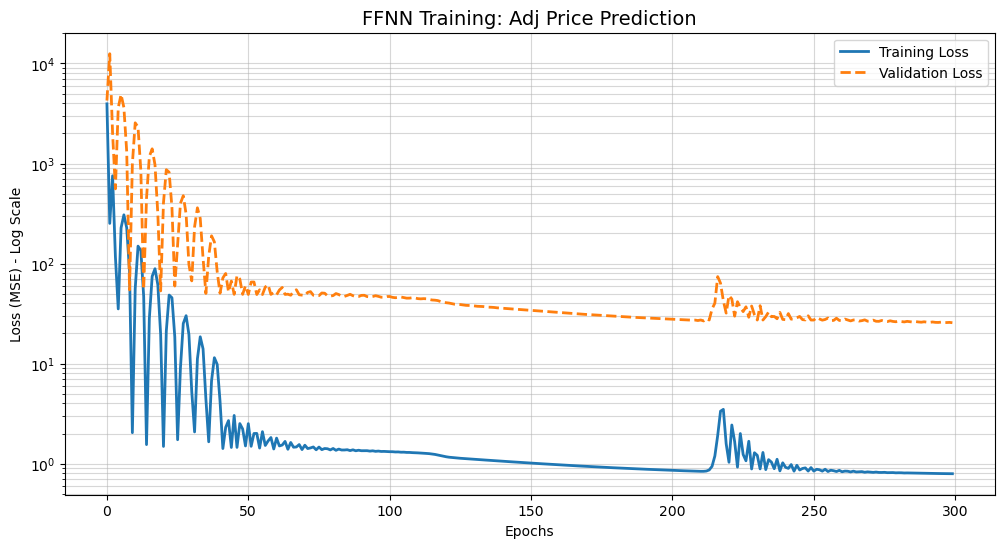

In [422]:
def plot_learning_curves(train_history, val_history, title="Model Learning Curves"):
    """
    Visualizes the evolution of the loss during training.
    """
    plt.figure(figsize=(12, 6))

    # Plotting both curves
    plt.plot(train_history, label='Training Loss', color='tab:blue', linewidth=2)
    plt.plot(val_history, label='Validation Loss', color='tab:orange', linewidth=2, linestyle='--')

    # Use logarithmic scale if the initial loss is much higher than the final loss
    if max(train_history) / (min(train_history) + 1e-6) > 100:
        plt.yscale('log')
        plt.ylabel('Loss (MSE) - Log Scale')
    else:
        plt.ylabel('Loss (MSE)')

    plt.title(title, fontsize=14)
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

# Call the function with our results
plot_learning_curves(train_losses, val_losses, title="FFNN Training: Adj Price Prediction")

In [423]:
# Load the saved weights from our checkpoint
model.load_state_dict(torch.load('best_model_params.pth', map_location=device))

# Set the model to evaluation mode
model.eval()

print("Best model parameters loaded and model set to evaluation mode.")

Best model parameters loaded and model set to evaluation mode.


In [424]:
# Generate predictions for the test set
with torch.no_grad():
    # Forward pass through the model
    y_pred_tensor = model(X_test_t)

    # Move the result back to CPU and convert to a NumPy array
    # .numpy() only works on CPU tensors, so we call .cpu() first
    y_pred_ffnn = y_pred_tensor.cpu().numpy()

print(f"Generated {len(y_pred_ffnn)} predictions for the test period (2023-2025).")

Generated 752 predictions for the test period (2023-2025).


In [425]:
# We use the original NumPy array for the ground truth (y_test_np)
# Note: y_pred_ffnn is (Samples, 1), so we flatten it to (Samples,) to match y_test_np
y_pred_ffnn_flat = y_pred_ffnn.flatten()

# Calculate Mean Absolute Error (MAE)
mae_ffnn = np.mean(np.abs(y_test_np - y_pred_ffnn_flat))

# Calculate Mean Squared Error (MSE)
mse_ffnn = np.mean((y_test_np - y_pred_ffnn_flat)**2)

print(f"--- FFNN Test Results ---")
print(f"MAE: {mae_ffnn:.4f}")
print(f"MSE: {mse_ffnn:.4f}")

--- FFNN Test Results ---
MAE: 4.6231
MSE: 39.0048


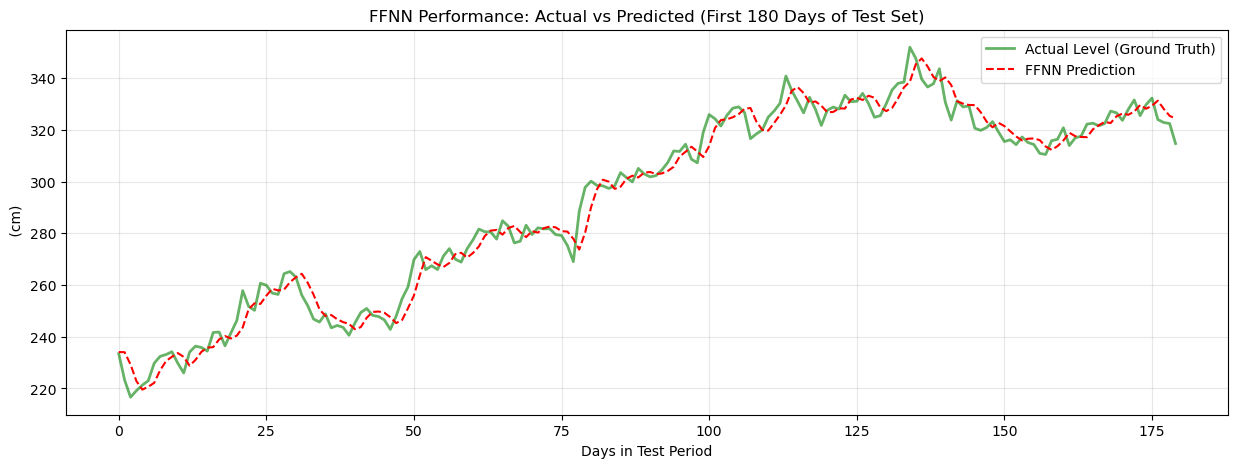

In [426]:
# We plot a 6-month window (approx 180 days) to see the detail
plt.figure(figsize=(15, 5))

plt.plot(y_test_np[:180], label='Actual Level (Ground Truth)', color='green', alpha=0.6, linewidth=2)
plt.plot(y_pred_ffnn_flat[:180], label='FFNN Prediction', color='red', linestyle='--', linewidth=1.5)

plt.title("FFNN Performance: Actual vs Predicted (First 180 Days of Test Set)")
plt.ylabel(" (cm)")
plt.xlabel("Days in Test Period")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Tuning

Use of the early stopping method (in this case class) where we stop the training phase before the model goes in overfitting 

In [427]:
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0, path='best_checkpoint.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"Early stopping triggered after {self.counter} epochs without improvement.")
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.path)

In [428]:
# Setup early stopping inside the training loop 
model = nn.Sequential(
    nn.Linear(window_size, 256), 
    nn.ReLU(), 
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Initialize Early Stopping
early_stopper = EarlyStopping(patience=30, min_delta=0.01)

n_epochs = 1000 
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    # 1. Training
    model.train()
    optimizer.zero_grad()
    t_out = model(X_train_t)
    t_loss = criterion(t_out, y_train_t)
    t_loss.backward()
    optimizer.step()

    # 2. Validation
    model.eval()
    with torch.no_grad():
        v_out = model(X_val_t)
        v_loss = criterion(v_out, y_val_t)

    train_losses.append(t_loss.item())
    val_losses.append(v_loss.item())

    # 3. Check for Early Stopping
    early_stopper(v_loss.item(), model)

    if early_stopper.early_stop:
        print(f"Stopping at epoch {epoch}")
        break

# 4. Final step: Load the best weights saved by the early stopper
model.load_state_dict(torch.load('best_checkpoint.pth'))

Early stopping triggered after 30 epochs without improvement.
Stopping at epoch 469


<All keys matched successfully>

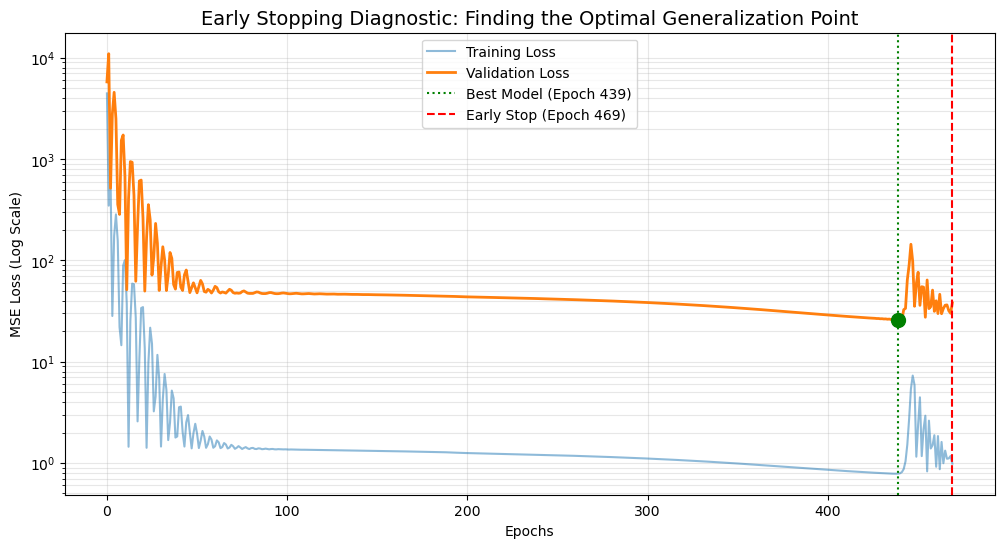

In [429]:
# Visualizing the early stopping point 
def plot_early_stopping(train_losses, val_losses):
    plt.figure(figsize=(12, 6))

    # 1. Plot the loss curves
    plt.plot(train_losses, label='Training Loss', color='tab:blue', alpha=0.5)
    plt.plot(val_losses, label='Validation Loss', color='tab:orange', linewidth=2)

    # 2. Find the best epoch (minimum validation loss)
    best_epoch = np.argmin(val_losses)
    best_val_loss = val_losses[best_epoch]

    # 3. Mark the Best Point
    plt.axvline(x=best_epoch, color='green', linestyle=':', label=f'Best Model (Epoch {best_epoch})')
    plt.scatter(best_epoch, best_val_loss, color='green', s=100, zorder=5)

    # 4. Mark the Stop Point
    stop_epoch = len(train_losses) - 1
    plt.axvline(x=stop_epoch, color='red', linestyle='--', label=f'Early Stop (Epoch {stop_epoch})')

    # Formatting
    plt.title("Early Stopping Diagnostic: Finding the Optimal Generalization Point", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss (Log Scale)")
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)


    plt.show()

# Call the function
plot_early_stopping(train_losses, val_losses)

## Regularization

Keeping the weights small: 
$$\text{Total Loss} = \text{MSE Loss} + \text{Regularization Penalty}$$
- L1 -> weights to become zero.
- L2 -> weights to become near zero.

In [430]:
def train_with_regularization(model, X, y, reg_type=None, lambda_reg=0.01):
    """
    Example of how to apply L1 or L2 regularization during training.
    """
    criterion = nn.MSELoss()

    # L2 is handled here via weight_decay
    wd = lambda_reg
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)

    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    mse_loss = criterion(outputs, y)

    # L1 is handled manually
    if reg_type == 'L1':
        l1_penalty = 0
        for param in model.parameters():
            l1_penalty += torch.norm(param, 1) # Sum of absolute values
        total_loss = mse_loss + lambda_reg * l1_penalty
    else:
        total_loss = mse_loss

    total_loss.backward()
    optimizer.step()

    return total_loss.item()

Reproducibility set with seed: 42
Reproducibility set with seed: 42
Reproducibility set with seed: 42


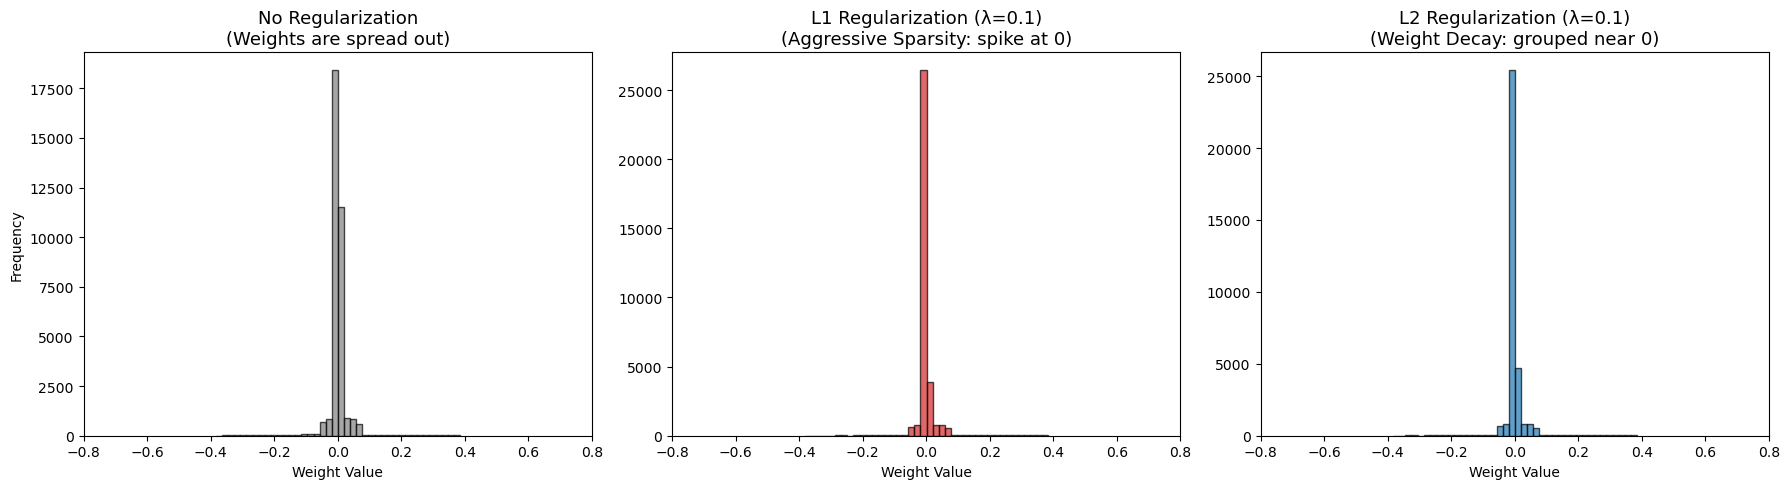

In [431]:
# Models without reg, with L1 and with L2
class PriceForecaster(nn.Module):
    def __init__(self, input_dim):
        super(PriceForecaster, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

def get_weights(model):
    """Helper to extract all weights from the model as a single numpy array."""
    weights = []
    for param in model.parameters():
        # Move to CPU before converting to numpy
        weights.append(param.view(-1).detach().cpu().numpy())
    return np.concatenate(weights)

# --- Experiment Settings ---
epochs = 150 # Increased slightly to see a stronger effect
lambda_val = 0.1 # High value for visual clarity

# 1. Train Model WITHOUT Regularization
set_reproducibility(42)
model_none = PriceForecaster(window_size).to(device)
for _ in range(epochs):
    train_with_regularization(model_none, X_train_t, y_train_t, reg_type=None)

# 2. Train Model WITH L1 (Sparsity)
set_reproducibility(42)
model_l1 = PriceForecaster(window_size).to(device)
for _ in range(epochs):
    train_with_regularization(model_l1, X_train_t, y_train_t, reg_type='L1', lambda_reg=lambda_val)

# 3. Train Model WITH L2 (Weight Decay)
set_reproducibility(42)
model_l2 = PriceForecaster(window_size).to(device)
for _ in range(epochs):
    train_with_regularization(model_l2, X_train_t, y_train_t, reg_type='L2', lambda_reg=lambda_val)

# --- Plotting the Results ---
plt.figure(figsize=(18, 5))

# Plot 1: No Regularization
plt.subplot(1, 3, 1)
plt.hist(get_weights(model_none), bins=40, color='gray', edgecolor='black', alpha=0.7)
plt.title("No Regularization\n(Weights are spread out)", fontsize=13)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.xlim(-0.8, 0.8) # Keep x-axis consistent for comparison

# Plot 2: L1
plt.subplot(1, 3, 2)
plt.hist(get_weights(model_l1), bins=40, color='tab:red', edgecolor='black', alpha=0.7)
plt.title(f"L1 Regularization (λ={lambda_val})\n(Aggressive Sparsity: spike at 0)", fontsize=13)
plt.xlabel("Weight Value")
plt.xlim(-0.8, 0.8)

# Plot 3: L2
plt.subplot(1, 3, 3)
plt.hist(get_weights(model_l2), bins=40, color='tab:blue', edgecolor='black', alpha=0.7)
plt.title(f"L2 Regularization (λ={lambda_val})\n(Weight Decay: grouped near 0)", fontsize=13)
plt.xlabel("Weight Value")
plt.xlim(-0.8, 0.8)

plt.tight_layout()
plt.show()

It doesn't change so much between the three different configurations: why?

## Using the Dropout Layer 

Randomly deactivation a custom percentage of neurons in the hidden layers.

In [432]:
# Model with dropout 
def train_scenario(h_size, epochs, lr, dropout_p=0.0):
    """
    Trains a model on the 'tiny' dataset to demonstrate overfitting/dropout.
    """
    model = nn.Sequential(
        nn.Linear(window_size, h_size),
        nn.ReLU(),
        nn.Dropout(dropout_p), # This is the only difference
        nn.Linear(h_size, h_size // 2),
        nn.ReLU(),
        nn.Dropout(dropout_p),
        nn.Linear(h_size // 2, 1)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    t_h, v_h = [], []
    for _ in range(epochs):
        # --- Training ---
        model.train() # IMPORTANT: Dropout is ACTIVE here
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        t_h.append(loss.item())

        # --- Validation ---
        model.eval() # IMPORTANT: Dropout is DEACTIVATED here
        with torch.no_grad():
            # We validate on the FULL validation set to see if it generalizes
            v_h.append(criterion(model(X_val_t), y_val_t).item())

    return t_h, v_h

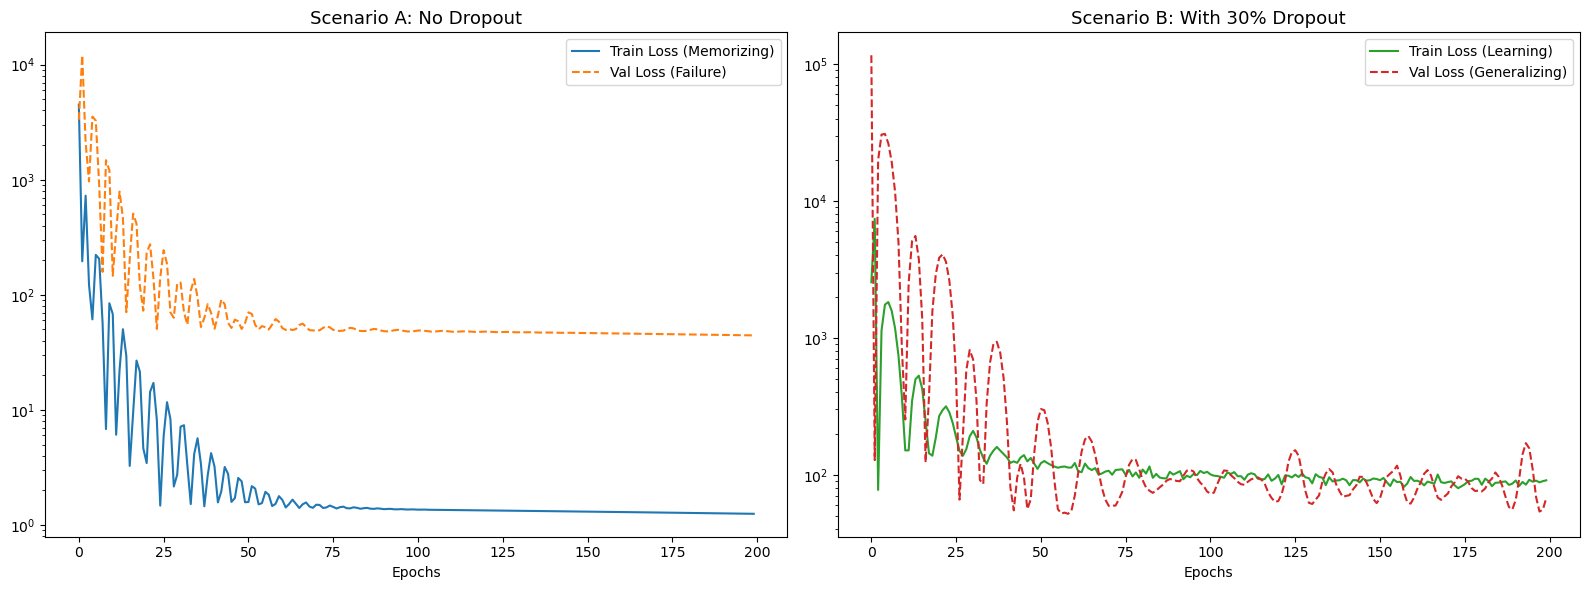

In [433]:
# Run Experiment 1: Overfitting (No Dropout)
t_over, v_over = train_scenario(h_size=256, epochs=200, lr=0.01, dropout_p=0.0)

# Run Experiment 2: Robust Learning (50% Dropout)
t_drop, v_drop = train_scenario(h_size=256, epochs=200, lr=0.01, dropout_p=0.3)

# --- Plot the comparison ---
plt.figure(figsize=(16, 6))

# Left Plot: No Dropout
plt.subplot(1, 2, 1)
plt.plot(t_over, label='Train Loss (Memorizing)', color='tab:blue')
plt.plot(v_over, label='Val Loss (Failure)', color='tab:orange', linestyle='--')
plt.yscale('log')
plt.title("Scenario A: No Dropout", fontsize=13)
plt.xlabel("Epochs")
plt.legend()

# Right Plot: With Dropout
plt.subplot(1, 2, 2)
plt.plot(t_drop, label='Train Loss (Learning)', color='tab:green')
plt.plot(v_drop, label='Val Loss (Generalizing)', color='tab:red', linestyle='--')
plt.yscale('log')
plt.title("Scenario B: With 30% Dropout", fontsize=13)
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
plt.show()

## Grid Search: hyperparameter tuning 

In [434]:
class FlexibleFFNN(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        """
        Args:
            hidden_layers (list): List containing neurons for each hidden layer.
                                  e.g., [64, 32] creates 2 layers.
        """
        super(FlexibleFFNN, self).__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1)) 
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1)) # Output layer
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [435]:
search_grid = {
    'learning_rate': [0.01, 0.001], # Added a finer learning rate for deeper models
    'batch_size': [32, 64],                # Standard stable sizes
    'architecture': [
        [512],
        [256],
        [256, 128],
    ]
}

n_retrains = 2
tuning_results = []

print(f"Starting Grid Search...")

# Loop 
for lr in search_grid['learning_rate']:
    for b_size in search_grid['batch_size']:
        for arch in search_grid['architecture']:

            # Prepare DataLoaders for this specific batch size
            train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=b_size, shuffle=True)
            val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=b_size)

            run_mse_scores = []
            print(f"Testing: LR={lr}, Batch={b_size}, Arch={arch}...", end=" ")

            # --- 3. Retrain n times to ensure stability ---
            for run in range(n_retrains):
                set_reproducibility(run) # New seed for each run

                model = FlexibleFFNN(window_size, arch).to(device)
                optimizer = optim.Adam(model.parameters(), lr=lr)
                criterion = nn.MSELoss()

                # Simple training loop for tuning (shorter epochs for speed)
                for epoch in range(500):
                    model.train()
                    for bx, by in train_loader:
                        optimizer.zero_grad()
                        loss = criterion(model(bx), by)
                        loss.backward()
                        optimizer.step()

                # Evaluate on Validation Set
                model.eval()
                with torch.no_grad():
                    val_mse = criterion(model(X_val_t), y_val_t).item()
                run_mse_scores.append(val_mse)

            # Compute average performance
            avg_mse = np.mean(run_mse_scores)
            print(f"Avg Val MSE: {avg_mse:.4f}")

            tuning_results.append({
                'lr': lr,
                'batch_size': b_size,
                'layers': len(arch),
                'neurons': arch[0],
                'val_mse': avg_mse
            })

# Summarize Results
df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by='val_mse', ascending=True)

print("\n--- Grid Search Results ---")
display(df_tuning)

Starting Grid Search...
Testing: LR=0.01, Batch=32, Arch=[512]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 200.4879
Testing: LR=0.01, Batch=32, Arch=[256]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 116.6257
Testing: LR=0.01, Batch=32, Arch=[256, 128]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 511.2437
Testing: LR=0.01, Batch=64, Arch=[512]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 36.7555
Testing: LR=0.01, Batch=64, Arch=[256]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 389.5491
Testing: LR=0.01, Batch=64, Arch=[256, 128]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 156.4521
Testing: LR=0.001, Batch=32, Arch=[512]... Reproducibility set with seed: 0
Reproducibility set with seed: 1
Avg Val MSE: 27.8628
Testing: LR=0.001, Batch=32, Arch=[256]... Reproducibilit

,lr,batch_size,layers,neurons,val_mse
8,0.001,32,2,256,24.442820
6,0.001,32,1,512,27.862790
10,0.001,64,1,256,33.482573
3,0.010,64,1,512,36.755484
7,0.001,32,1,256,38.519019
9,0.001,64,1,512,40.999880
1,0.010,32,1,256,116.625715
11,0.001,64,2,256,121.721897
5,0.010,64,2,256,156.452114
0,0.010,32,1,512,200.487949


In [437]:
best_params = df_tuning.iloc[0]
print(f"\nWINNING CONFIGURATION:")
print(f"Learning Rate: {best_params['lr']}")
print(f"Batch Size: {int(best_params['batch_size'])}")
print(f"Layers: {int(best_params['layers'])}")
print(f"Neurons in first layer: {int(best_params['neurons'])}")


WINNING CONFIGURATION:
Learning Rate: 0.001
Batch Size: 32
Layers: 2
Neurons in first layer: 256


In [438]:
# Set Winning Hyperparameters 
best_lr = 0.001
best_batch_size = 32
best_arch = [256, 128]

# Initialize Model, Optimizer, and DataLoaders 
set_reproducibility(42) # Ensure final run is stable
final_model = FlexibleFFNN(window_size, best_arch).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.MSELoss()

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=best_batch_size)

# Final Training with Early Stopping
early_stopper = EarlyStopping(patience=30, path='final_optimized_model.pth')
n_epochs = 1000

for epoch in range(n_epochs):
    final_model.train()
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(bx), by)
        loss.backward()
        optimizer.step()

    # Validation check for Early Stopping
    final_model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(final_model(vx), vy).item() for vx, vy in val_loader) / len(val_loader)

    early_stopper(val_loss, final_model)
    if early_stopper.early_stop:
        print(f"Final training stopped at epoch {epoch}")
        break

# Load the best weights found during this final run
final_model.load_state_dict(torch.load('final_optimized_model.pth'))
print("Optimized model is ready for testing.")

Reproducibility set with seed: 42
Early stopping triggered after 30 epochs without improvement.
Final training stopped at epoch 198
Optimized model is ready for testing.


In [442]:
# Evaluation on the test set 
final_model.eval()
with torch.no_grad():
    y_pred_tensor = final_model(X_test_t)
    y_pred_optimized = y_pred_tensor.cpu().numpy().flatten()

mae_final = np.mean(np.abs(y_test_np - y_pred_optimized))
mse_final = np.mean((y_test_np - y_pred_optimized)**2)
rmse_final = np.sqrt(mse_final)
mape_final = np.mean(np.abs((y_test_np - y_pred_optimized) / y_test_np))
r2_final = 1 - mse_final / np.mean((y_test_np - y_test_np.mean())**2)

print(f"--- Optimized FFNN Test Results ---")
print(f"MAE:  {mae_final:.4f}")
print(f"MSE:  {mse_final:.4f}")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAPE: {mape_final:.4f}")
print(f"R2:   {r2_final:.4f}")

--- Optimized FFNN Test Results ---
MAE:  4.4016
MSE:  35.3228
RMSE: 5.9433
MAPE: 0.0115
R2:   0.9938


## Multivariate Optimization 

We use the logic implemented for the linear model with X covariates here with the class of feed forward model. 

In [93]:
# Create the dataset using the parameters and the function defined 
target_col = 'adjprice'
window_size = 7
lead_time = 1

exog_cols = ['volume', 'oil', 'gold', 'sp500', 'vix', 'rates_10y']
arx_cols = [target_col] + exog_cols
data_multi = data[arx_cols].copy()

print(f"--- Multivariate Setup ---")
print(f"Features selected: {arx_cols}")
print(f"Total dataframe shape: {data_multi.shape}")

--- Multivariate Setup ---
Features selected: ['adjprice', 'volume', 'oil', 'gold', 'sp500', 'vix', 'rates_10y']
Total dataframe shape: (4024, 7)


In [94]:
data_multi.describe()

,adjprice,volume,oil,gold,sp500,vix,rates_10y
count,4024.000000,4.024000e+03,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,149.293493,3.529555e+07,71.532062,1663.167211,2945.011381,18.412875,2.604174
std,145.119517,2.058245e+07,20.799435,584.726810,1491.073720,6.873274,1.004028
min,17.315042,5.855900e+06,-37.630001,1050.800049,1022.580017,9.140000,0.499000
25%,30.767126,2.192250e+07,54.167499,1268.475006,1805.630035,13.770000,1.853000
50%,78.815315,2.938710e+07,71.555000,1505.700012,2584.730103,16.660000,2.458500
75%,250.818756,4.318792e+07,88.265001,1830.049988,4078.204956,21.100000,3.334750
max,539.825256,3.193179e+08,123.699997,4529.100098,6932.049805,82.690002,4.988000


In [ ]:
# Fix for the scale of the feature input (it counts here) only on the train set 
# Scaling the features because from previous plot std each feature is very different from each other 
# Robust scaler -> better for real word data -> https://machinelearningmastery.com/minmax-vs-standard-vs-robust-scaler-which-one-wins-for-skewed-data/

# Scaling of the feature 
exog_scaler = RobustScaler()
train_mask = data_multi.index <= '2019-12-31'

data_multi_scaled = data_multi.copy()
data_multi_scaled.loc[train_mask, exog_cols] = exog_scaler.fit_transform(data_multi.loc[train_mask, exog_cols])
data_multi_scaled.loc[~train_mask, exog_cols] = exog_scaler.transform(data_multi.loc[~train_mask, exog_cols])

In [96]:
def create_multivariate_dataset(data, window_size, lead_time=1):
    """
    Transforms multivariate time series into a flat vector for FFNN.

    Standard FFNN layers (nn.Linear) expect a 1D input vector per sample.
    Therefore, a window of 7 days with 2 features (7x2 matrix) must be
    flattened into a 14-element vector.
    """
    X, y = [], []
    values = data.values
    target_values = data.iloc[:, 0].values 

    for i in range(len(values) - window_size - lead_time + 1):
        # Extract the 2D window (e.g., shape 7x2)
        window_2d = values[i : i + window_size]

        # Flatten the window to 1D (e.g., 14 elements)
        # Sequence: [Day1_Lev, Day1_Temp, Day2_Lev, Day2_Temp ... Day7_Temp]
        window_flat = window_2d.flatten()

        X.append(window_flat)
        y.append(target_values[i + window_size + lead_time - 1])

    return np.array(X), np.array(y)

In [97]:
# Creating the arrays 
X_multi_raw, y_multi_raw = create_multivariate_dataset(data_multi_scaled, window_size = window_size, lead_time = lead_time)

print(f"\n--- Sliding Window Transformation ---")
print(f"Original Window Shape: ({window_size} days, {len(arx_cols)} features)")
print(f"Flattened Input Shape (X): {X_multi_raw.shape} (Samples, Features*Window)")
print(f"Target Vector Shape (y): {y_multi_raw.shape}")


--- Sliding Window Transformation ---
Original Window Shape: (7 days, 7 features)
Flattened Input Shape (X): (4017, 49) (Samples, Features*Window)
Target Vector Shape (y): (4017,)


In [98]:
# Split 
X_train_m_np, y_train_m_np = X_multi_raw[:train_end_idx], y_multi_raw[:train_end_idx]
X_val_m_np, y_val_m_np     = X_multi_raw[train_end_idx:val_end_idx], y_multi_raw[train_end_idx:val_end_idx]
X_test_m_np, y_test_m_np   = X_multi_raw[val_end_idx:], y_multi_raw[val_end_idx:]

print(f"\n--- Data Splits (NumPy) ---")
print(f"Train samples: {len(X_train_m_np)} | Val samples: {len(X_val_m_np)} | Test samples: {len(X_test_m_np)}")


--- Data Splits (NumPy) ---
Train samples: 2509 | Val samples: 756 | Test samples: 752


In [99]:
# Convert to tensors
X_train_m = torch.tensor(X_train_m_np, dtype=torch.float32).to(device)
y_train_m = torch.tensor(y_train_m_np, dtype=torch.float32).view(-1, 1).to(device)

X_val_m   = torch.tensor(X_val_m_np, dtype=torch.float32).to(device)
y_val_m   = torch.tensor(y_val_m_np, dtype=torch.float32).view(-1, 1).to(device)

X_test_m  = torch.tensor(X_test_m_np, dtype=torch.float32).to(device)
y_test_m  = torch.tensor(y_test_m_np, dtype=torch.float32).view(-1, 1).to(device)

In [100]:
# Check-up 
input_dim_multi = X_train_m.shape[1]

print(f"\n--- Final PyTorch Tensors ---")
print(f"X_train_m shape: {X_train_m.shape} (Note the 14 columns)")
print(f"y_train_m shape: {y_train_m.shape} (Reshaped for Loss Function)")
print(f"Success: The model will now receive {input_dim_multi} inputs per sample.")
print(f"Calculation: {window_size} days * {len(arx_cols)} features = {input_dim_multi} inputs.")


--- Final PyTorch Tensors ---
X_train_m shape: torch.Size([2509, 49]) (Note the 14 columns)
y_train_m shape: torch.Size([2509, 1]) (Reshaped for Loss Function)
Success: The model will now receive 49 inputs per sample.
Calculation: 7 days * 7 features = 49 inputs.


### Multivariate Hyperparameter Grid Search 

In [ ]:
# Multisearch grid 
search_grid_multi = {
    'learning_rate': [0.01, 0.001], # Added a finer learning rate for deeper models
    'batch_size': [32, 64],                # Standard stable sizes
    'architecture': [
        [128],
        [64, 32],
        [128, 64, 32]
    ]
}

# Calculate total iterations to help track progress
total_combinations = (len(search_grid_multi['learning_rate']) *
                      len(search_grid_multi['batch_size']) *
                      len(search_grid_multi['architecture']))

tuning_results_multi = []
iteration = 0

print(f"--- Starting Multivariate Grid Search ---")
print(f"Total combinations to test: {total_combinations}")
print(f"Training each for 300 epochs...")

# --- THE GRID SEARCH LOOP ---
for lr in search_grid_multi['learning_rate']:
    for b_size in search_grid_multi['batch_size']:
        for arch in search_grid_multi['architecture']:
            iteration += 1

            # 1. Setup DataLoader for the current batch size
            # We shuffle training data to improve gradient estimation
            train_loader = DataLoader(TensorDataset(X_train_m, y_train_m),
                                      batch_size=b_size,
                                      shuffle=True)

            # 2. Re-initialize weight reproducibility
            # This ensures that architecture [32] with LR=0.01 starts from the same
            # random weights as [32] with LR=0.001, making the comparison fair.
            set_reproducibility(42)

            # 3. Build the model instance
            model = FlexibleFFNN(input_dim_multi, arch).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = nn.MSELoss()

            # 4. "Fast" Training Loop
            # We use a fixed number of epochs (300) for the search phase
            # to compare how configurations converge under the same conditions.
            model.train()
            for epoch in range(300):
                for bx, by in train_loader:
                    optimizer.zero_grad()
                    output = model(bx)
                    loss = criterion(output, by)
                    loss.backward()
                    optimizer.step()

            # 5. Evaluate on the VALIDATION SET
            # IMPORTANT: We never tune hyperparameters on the Test Set.
            model.eval()
            with torch.no_grad():
                # We calculate the loss on the entire validation tensor
                val_mse = criterion(model(X_val_m), y_val_m).item()

            # 6. Store the results for later analysis
            tuning_results_multi.append({
                'lr': lr,
                'batch_size': b_size,
                'arch': str(arch), # Store as string for easy display in DataFrame
                'val_mse': val_mse
            })

            # 7. Progress Print
            print(f"[{iteration}/{total_combinations}] | LR: {lr:<6} | BS: {b_size:<3} | Arch: {str(arch):<15} | Val MSE: {val_mse:.4f}")

# ANALYZE RESULTS
# Convert the list of dictionaries into a Pandas DataFrame for sorting
df_tuning_multi = pd.DataFrame(tuning_results_multi).sort_values('val_mse', ascending=True)

print(f"\n--- Grid Search Complete ---")
print(f"The best configuration found has a Validation MSE of: {df_tuning_multi.iloc[0]['val_mse']:.4f}")

# Display the top 3 best models
print("\nTop 3 Multivariate Configurations (Ranked by Validation MSE):")
display(df_tuning_multi.head(3))

# Final check: Which parameters won?
best_m_params = df_tuning_multi.iloc[0]
print(f"\nWINNER -> LR: {best_m_params['lr']}, Batch: {best_m_params['batch_size']}, Architecture: {best_m_params['arch']}")

--- Starting Multivariate Grid Search ---
Total combinations to test: 12
Training each for 300 epochs...
Reproducibility set with seed: 42
[1/12] | LR: 0.01   | BS: 32  | Arch: [128]           | Val MSE: 37.7545
Reproducibility set with seed: 42
[2/12] | LR: 0.01   | BS: 32  | Arch: [64, 32]        | Val MSE: 400.2420
Reproducibility set with seed: 42
[3/12] | LR: 0.01   | BS: 32  | Arch: [128, 64, 32]   | Val MSE: 1158.7140
Reproducibility set with seed: 42
[4/12] | LR: 0.01   | BS: 64  | Arch: [128]           | Val MSE: 37.6058
Reproducibility set with seed: 42
[5/12] | LR: 0.01   | BS: 64  | Arch: [64, 32]        | Val MSE: 172.1438
Reproducibility set with seed: 42
[6/12] | LR: 0.01   | BS: 64  | Arch: [128, 64, 32]   | Val MSE: 36.3829
Reproducibility set with seed: 42
[7/12] | LR: 0.001  | BS: 32  | Arch: [128]           | Val MSE: 75.5226
Reproducibility set with seed: 42
[8/12] | LR: 0.001  | BS: 32  | Arch: [64, 32]        | Val MSE: 290.0533
Reproducibility set with seed: 42


,lr,batch_size,arch,val_mse
9,0.001,64,[128],34.323757
8,0.001,32,"[128, 64, 32]",34.811790
5,0.010,64,"[128, 64, 32]",36.382915



WINNER -> LR: 0.001, Batch: 64, Architecture: [128]


In [105]:
# Full training run with the parameters selected 
print(f"--- Preparing Final Multivariate Production Run ---")

# --- 1. Extract Winning Parameters ---
best_lr_m = 0.001
best_bs_m = 64

# SAFETY CHECK: If 'arch' is already a list, use it. If it's a string, convert it.
# This prevents the "ValueError: malformed node or string"
best_arch_m = [128]
if isinstance(best_arch_m, str):
    import ast
    best_arch_m = ast.literal_eval(best_arch_m)

print(f"Winning Architecture: {best_arch_m}")
print(f"Winning Learning Rate: {best_lr_m}")
print(f"Winning Batch Size: {best_bs_m}")

# --- 2. Initialize Final Model, Optimizer, and Early Stopper ---

# Create the optimized model instance with the multivariate input dimension (14)
final_multi_model = FlexibleFFNN(input_dim_multi, best_arch_m).to(device)

# Initialize the optimizer with the winning learning rate
optimizer = optim.Adam(final_multi_model.parameters(), lr=best_lr_m)

# Initialize Early Stopping
# Patience=30: We will stop if the Val Loss doesn't improve for 30 consecutive epochs.
early_stopper_m = EarlyStopping(patience=50, path='final_multi_optimized.pth')

# Prepare the final DataLoaders
train_loader_m = DataLoader(TensorDataset(X_train_m, y_train_m),
                            batch_size=best_bs_m,
                            shuffle=True)

val_loader_m   = DataLoader(TensorDataset(X_val_m, y_val_m),
                            batch_size=best_bs_m)

print(f"\nFinal Training Started...")

# --- 3. The Production Training Loop ---
n_epochs = 1000
for epoch in range(n_epochs):

    # --- PHASE A: TRAINING ---
    final_multi_model.train()
    train_loss_accum = 0
    for bx, by in train_loader_m:
        optimizer.zero_grad()
        output = final_multi_model(bx)
        loss = criterion(output, by)
        loss.backward()
        optimizer.step()
        train_loss_accum += loss.item()

    avg_train_loss = train_loss_accum / len(train_loader_m)

    # --- PHASE B: VALIDATION ---
    final_multi_model.eval()
    val_loss_accum = 0
    with torch.no_grad():
        for vx, vy in val_loader_m:
            v_out = final_multi_model(vx)
            v_loss = criterion(v_out, vy)
            val_loss_accum += v_loss.item()

    avg_val_loss = val_loss_accum / len(val_loader_m)

    # --- PHASE C: EARLY STOPPING LOGIC ---
    # The stopper checks for improvement and saves the best model weights.
    early_stopper_m(avg_val_loss, final_multi_model)

    # Print progress every 50 epochs to keep the console clean
    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{n_epochs}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

    if early_stopper_m.early_stop:
        print(f"(!) Early Stopping triggered at epoch {epoch}. Model generalization has peaked.")
        break

# --- 4. Load the Best Weights ---
# We "rewind" to the state where Validation Loss was at its absolute minimum.
final_multi_model.load_state_dict(torch.load('final_multi_optimized.pth'))

print("\nFinal Optimized Multivariate Model is now loaded and ready for final assessment.")

--- Preparing Final Multivariate Production Run ---
Winning Architecture: [128]
Winning Learning Rate: 0.001
Winning Batch Size: 64

Final Training Started...
Epoch [0/1000] | Train MSE: 592.8554 | Val MSE: 583.9483
Epoch [50/1000] | Train MSE: 9.2199 | Val MSE: 49.5236
Epoch [100/1000] | Train MSE: 8.1329 | Val MSE: 39.3326
Epoch [150/1000] | Train MSE: 8.5613 | Val MSE: 59.2284
Epoch [200/1000] | Train MSE: 8.2280 | Val MSE: 38.5243
Epoch [250/1000] | Train MSE: 7.2824 | Val MSE: 29.7131
Epoch [300/1000] | Train MSE: 7.3540 | Val MSE: 53.9872
Epoch [350/1000] | Train MSE: 7.8408 | Val MSE: 28.3296
Epoch [400/1000] | Train MSE: 8.3971 | Val MSE: 31.0324
Epoch [450/1000] | Train MSE: 7.8123 | Val MSE: 25.6658
Epoch [500/1000] | Train MSE: 7.7930 | Val MSE: 25.6871
Epoch [550/1000] | Train MSE: 8.3590 | Val MSE: 38.7867
Epoch [600/1000] | Train MSE: 7.6670 | Val MSE: 24.6789
Epoch [650/1000] | Train MSE: 10.8331 | Val MSE: 26.2871
Epoch [700/1000] | Train MSE: 7.9479 | Val MSE: 35.0131


In [106]:
# Test on the new data 
print(f"--- Final Evaluation on Test Set (2023-2025) ---")

# 1. Prediction Phase
final_multi_model.eval() # Ensure Dropout is OFF
with torch.no_grad():    # Disable gradient tracking to save memory/speed
    # Forward pass through the network
    y_pred_tensor = final_multi_model(X_test_m)

    # Move result back to CPU and convert to a flat NumPy array for metric calculation
    y_pred_multi = y_pred_tensor.cpu().numpy().flatten()

# 2. Calculate Final Metrics (using NumPy for consistency with Lecture 1)
# MSE penalizes large errors more heavily, which is crucial for flood risk.
mse_multi_final = np.mean((y_test_m_np - y_pred_multi)**2)
# MAE provides the average error in centimeters.
mae_multi_final = np.mean(np.abs(y_test_m_np - y_pred_multi))

print(f"Optimized Multivariate FFNN -> MSE: {mse_multi_final:.4f} | MAE: {mae_multi_final:.4f}")

--- Final Evaluation on Test Set (2023-2025) ---
Optimized Multivariate FFNN -> MSE: 35.0176 | MAE: 4.3494


--- FINAL COURSE PERFORMANCE LEADERBOARD ---


,MSE
Model,
Persistence (Naive),30.525300
Linear AR (Univariate),31.516300
Linear ARX (Multivariate),31.647300
"FFNN (Grid Search Optimized, Multivariate)",35.017634
"FFNN (Grid Search Optimized, Univariate)",35.322778
"FFNN (Untuned, Univariate)",39.004767


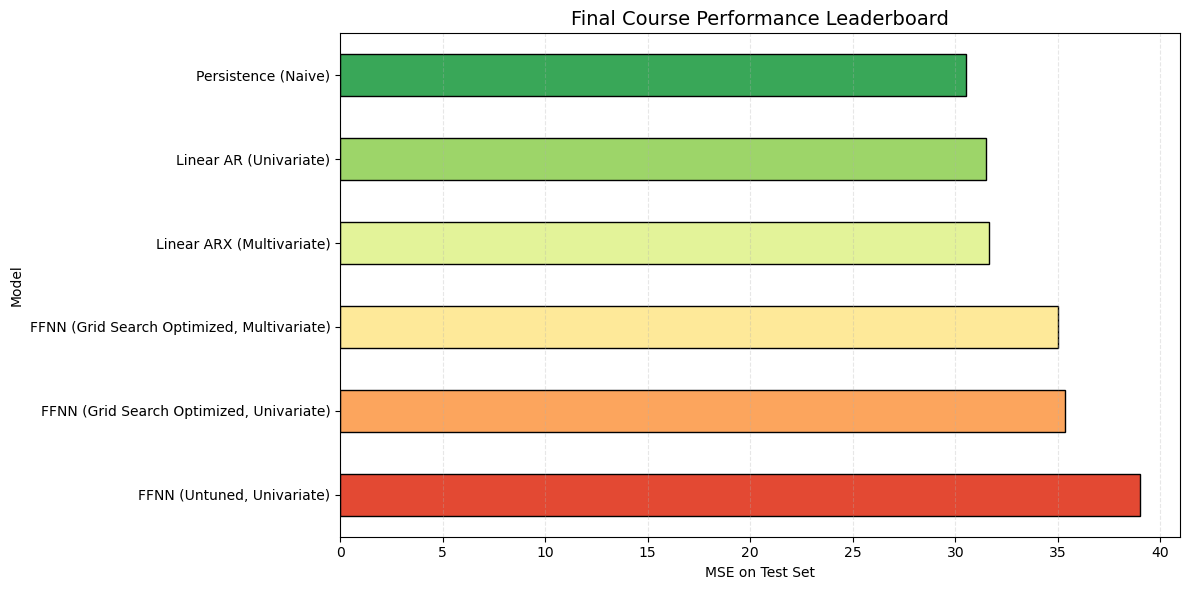

In [ ]:
# Assessment 
comparison_data = {
    "Model": [
        "Persistence (Naive)",
        "Linear AR (Univariate)",
        "Linear ARX (Multivariate)",
        "FFNN (Untuned, Univariate)",
        "FFNN (Grid Search Optimized, Univariate)",
        "FFNN (Grid Search Optimized, Multivariate)",
    ],
    "MSE": [
        30.5253,
        31.5163,
        31.6473,
        mse_ffnn,        # cell 18: untuned baseline
        mse_final,        # cell 39: optimized univariate
        mse_multi_final,  # cell 51: RE-RUN after the scaling fix
    ]
}

df_final = pd.DataFrame(comparison_data).set_index("Model").sort_values("MSE")

print("--- FINAL COURSE PERFORMANCE LEADERBOARD ---")
display(df_final)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("RdYlGn_r", len(df_final))
df_final['MSE'].plot(kind='barh', color=colors, edgecolor='black')
plt.title("Final Course Performance Leaderboard", fontsize=14)
plt.xlabel("MSE on Test Set")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()